# Assignment #3: Analyzing Drug Reviews

## Goals
- Clean and combine review text from **benefitsReview**, **sideEffectsReview**, and **commentsReview** to form an overall patient satisfaction review.
- Convert numeric **rating** into **class labels**.
- Analyze distribution of rating, average ratings per condition and per drugs.
- Use vader sentiment analysis and calculate accuracy of sentiment classification.
- generate word clouds and bar plots of most distinctive terms from positive and negative reviews.
- Use Bio_clinicalBERT transformer for sentiment classification.

<b> Total: 100pts



## Part I: Exploratory Data Analysis (40pts)

Install/Import libraries you need.

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


Load Data


In [2]:
train_df = pd.read_csv('/Users/thukzomm/Downloads/drug+review+dataset+druglib+com/drugLibTrain_raw.tsv', sep='\t')
test_df = pd.read_csv('/Users/thukzomm/Downloads/drug+review+dataset+druglib+com/drugLibTest_raw.tsv', sep='\t')


### Create the **Overall Patient Satisfaction Review**
Concatenate *benefitsReview + sideEffectsReview + commentsReview* into a single field `overall_review`.

In [3]:
train_df['overall_review'] = train_df['benefitsReview'].fillna('') + " " + \
                            train_df['sideEffectsReview'].fillna('') + " " + \
                            train_df['commentsReview'].fillna('')

test_df['overall_review'] = test_df['benefitsReview'].fillna('') + " " + \
                           test_df['sideEffectsReview'].fillna('') + " " + \
                           test_df['commentsReview'].fillna('')

### Convert **rating** to 2-Class Labels
Rules (as requested):
- `positive` if rating >5
- `negative` if rating <= 5


In [4]:
# Rules: positive if rating >5, negative if rating <= 5
train_df['actual_label'] = train_df['rating'].apply(lambda x: 'positive' if x > 5 else 'negative')
test_df['actual_label'] = test_df['rating'].apply(lambda x: 'positive' if x > 5 else 'negative')

In [5]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
 9   overall_review     3107 non-null   object
 10  actual_label       3107 non-null   object
dtypes: int64(2), object(9)
memory usage: 267.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         1036 

### 	Analyze distribution of ratings
Show a histogram of rating

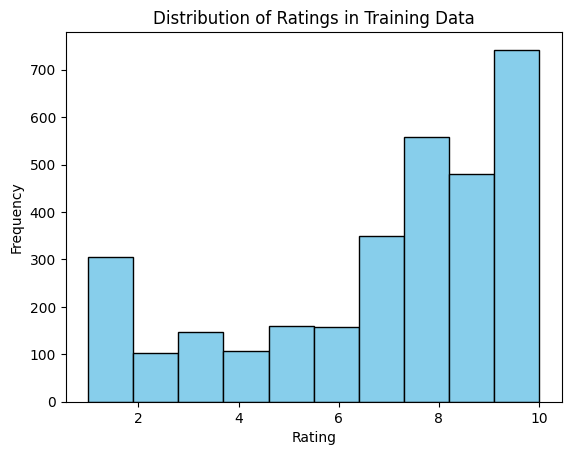

In [18]:
# Analyze distribution of ratings 
plt.hist(train_df['rating'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings in Training Data')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

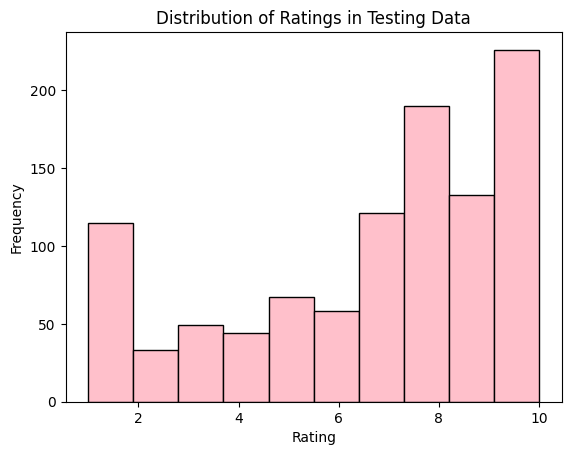

In [19]:
# Analyze distribution of ratings 
plt.hist(test_df['rating'], color='pink', edgecolor='black')
plt.title('Distribution of Ratings in Testing Data')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [20]:
# Show label distribution
print("Label Distribution in Training Data:")
print(train_df['actual_label'].value_counts())
print("\nLabel Distribution in Test Data:")
print(test_df['actual_label'].value_counts())

Label Distribution in Training Data:
actual_label
positive    2287
negative     820
Name: count, dtype: int64

Label Distribution in Test Data:
actual_label
positive    728
negative    308
Name: count, dtype: int64


### Top conditions by review count bar plot

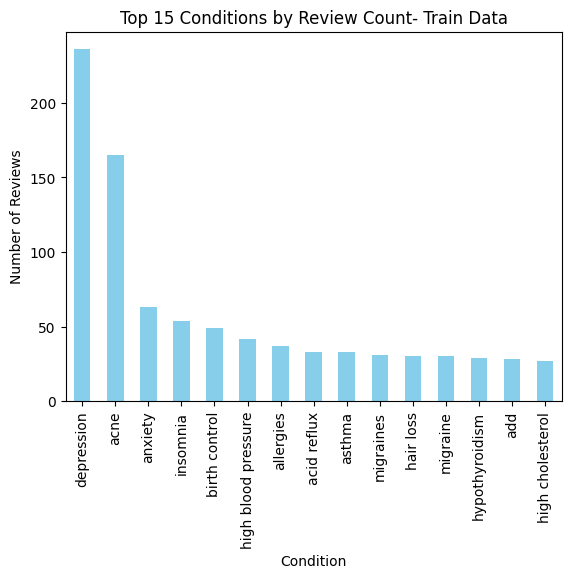

In [21]:
# Top conditions by review count bar plot
top_conditions_train = train_df['condition'].value_counts().head(15)
top_conditions_train.plot(kind='bar', color='skyblue')
plt.title('Top 15 Conditions by Review Count- Train Data')
plt.xlabel('Condition')
plt.ylabel('Number of Reviews')
plt.show()

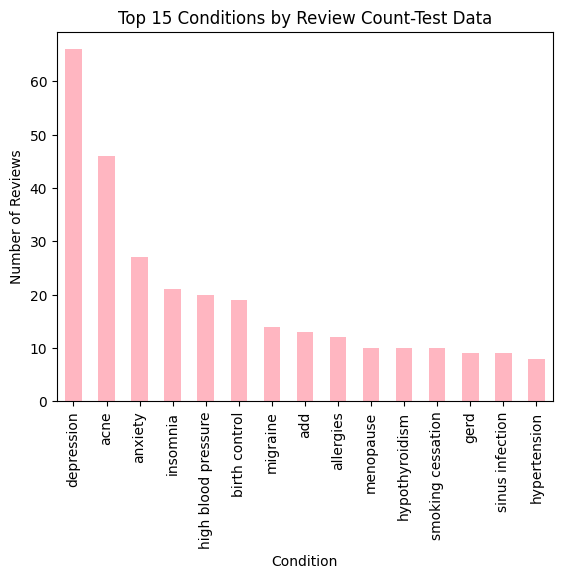

In [22]:
# Top conditions by review count bar plot
top_conditions_test = test_df['condition'].value_counts().head(15)
top_conditions_test.plot(kind='bar', color='lightpink')
plt.title('Top 15 Conditions by Review Count-Test Data')
plt.xlabel('Condition')
plt.ylabel('Number of Reviews')
plt.show()

### Average rating by condition to see which conditions have better treatment satisfaction.



Top 15 conditions by average rating (min 5 reviews) – TRAIN:
                   condition  mean  count   std
547                 glaucoma  9.20      5  0.84
96    ankylosing spondylitis  9.20      5  0.84
979            panic attacks  9.00      7  1.41
786         major depression  9.00      6  1.26
439                       ed  9.00      6  2.00
320               cold sores  8.88      8  1.13
534           genital herpes  8.80      5  1.30
1135    rheumatoid arthritis  8.69     16  1.35
1126   restless leg syndrome  8.57      7  1.40
810                menopause  8.50     12  2.84
54                adult acne  8.50      8  1.41
831       migraine headaches  8.38     13  2.33
56                 adult add  8.33      6  2.73
673              hypothyroid  8.27     11  2.65
141       anxiety/depression  8.25      8  2.71

Total unique conditions: 1426
Conditions with ≥5 reviews: 86


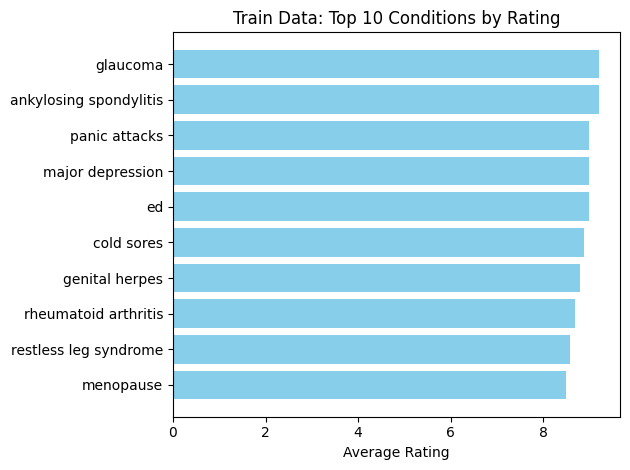

In [23]:
# Average rating by condition – TRAIN
train_condition_stats = (
    train_df
      .groupby("condition")["rating"]
      .agg(["mean", "count", "std"])
      .reset_index()
)

# Sort by average rating (descending)
train_condition_stats = train_condition_stats.sort_values("mean", ascending=False)

# Keep conditions with at least 5 reviews
train_condition_stats_filtered = train_condition_stats[train_condition_stats["count"]>=5]

print("\nTop 15 conditions by average rating (min 5 reviews) – TRAIN:")
print(train_condition_stats_filtered.head(15).round(2))

print(f"\nTotal unique conditions: {len(train_condition_stats)}")
print(f"Conditions with ≥5 reviews: {len(train_condition_stats_filtered)}")

# bar chart – top 10 conditions
top_train_conditions = train_condition_stats_filtered.head(10)
plt.barh(top_train_conditions["condition"], top_train_conditions["mean"], color='skyblue')
plt.xlabel("Average Rating")
plt.title("Train Data: Top 10 Conditions by Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Top 15 conditions by average rating (min 5 reviews) – TEST:
           condition  mean  count  std
             obesity  9.00      5 1.73
  seasonal allergies  8.80      5 1.10
                adhd  8.25      8 1.75
           migraines  8.17      6 1.33
              asthma  8.12      8 2.53
           hair loss  8.00      5 1.41
              herpes  8.00      5 2.35
           menopause  7.90     10 3.31
            migraine  7.79     14 1.85
rheumatoid arthritis  7.71      7 3.40
      hypothyroidism  7.70     10 2.91
                gerd  7.67      9 2.55
            insomnia  7.43     21 2.71
         hypothyroid  7.40      5 3.71
           allergies  7.25     12 2.60

Total unique conditions: 566
Conditions with ≥5 reviews: 32


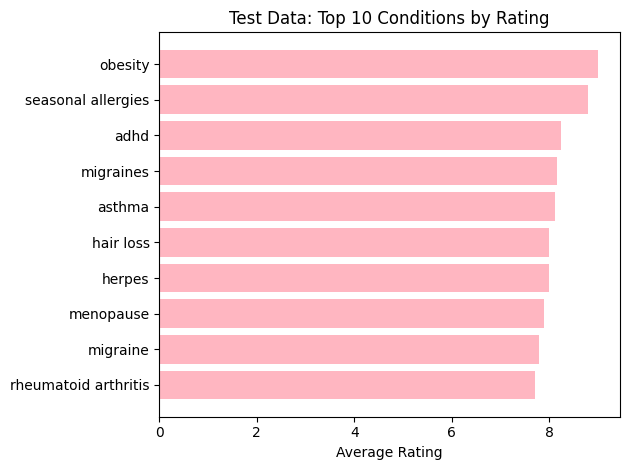

In [24]:
# Average rating by condition – TEST
test_condition_stats = (
    test_df
      .groupby("condition")["rating"]
      .agg(["mean", "count", "std"])
      .reset_index()
)

# Sort by average rating (descending)
test_condition_stats = test_condition_stats.sort_values("mean", ascending=False)

# Keep conditions with at least 5 reviews
test_condition_stats_filtered = test_condition_stats[test_condition_stats["count"] >= 5]

print("\nTop 15 conditions by average rating (min 5 reviews) – TEST:")
print(test_condition_stats_filtered.head(15).round(2).to_string(index=False))

print(f"\nTotal unique conditions: {len(test_condition_stats)}")
print(f"Conditions with ≥5 reviews: {len(test_condition_stats_filtered)}")

# bar chart – top 10 conditions
top_test_conditions = test_condition_stats_filtered.head(10)
plt.barh(top_test_conditions["condition"], top_test_conditions["mean"], color='lightpink')
plt.xlabel("Average Rating")
plt.title("Test Data: Top 10 Conditions by Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Top drugs by avg rating.


Top 20 drugs by average rating (min 5 reviews) – TRAIN:
        urlDrugName  mean  count   std
429        tenormin  9.40      5  0.89
262          maxalt  9.29      7  0.76
219         innofem  9.20      5  1.30
8         acyclovir  9.12      8  1.36
40   armour-thyroid  9.10     10  0.99
381          requip  9.00      6  1.67
456          valium  8.91     11  1.51
266         meridia  8.89      9  1.36
409          sotret  8.86      7  0.90
170         estrace  8.83      6  1.94
24       alprazolam  8.75      8  1.04
469     vivelle-dot  8.71      7  1.98
288          motrin  8.67     12  1.30
478           xanax  8.65     23  2.17
457         valtrex  8.64     22  1.18
208          humira  8.56      9  1.67
92           cialis  8.50      6  1.87
422         tamiflu  8.43      7  3.31
167          enbrel  8.40     10  2.67
190         flonase  8.40     25  1.76

Total unique drugs: 502
Drugs with ≥3 reviews: 187


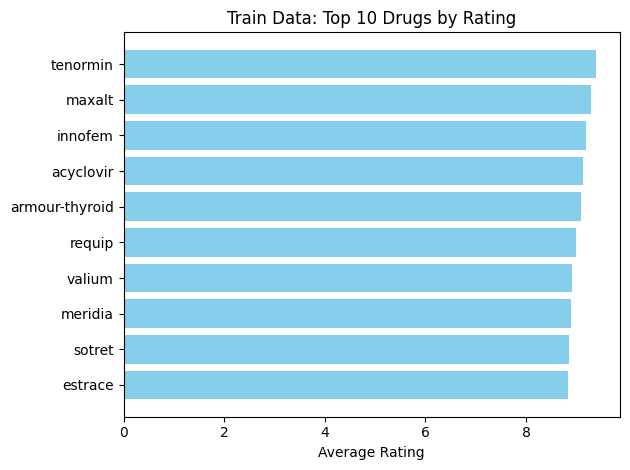

In [25]:
#Top drugs by average rating – TRAIN
train_drug_stats = (
    train_df
      .groupby("urlDrugName")["rating"]
      .agg(["mean", "count", "std"])
      .reset_index()
)

# Sort by average rating (descending)
train_drug_stats = train_drug_stats.sort_values("mean", ascending=False)

# Keep drugs with at least 5 reviews
train_drug_stats_filtered = train_drug_stats[train_drug_stats["count"] >=5]

print("\nTop 20 drugs by average rating (min 5 reviews) – TRAIN:")
print(train_drug_stats_filtered.head(20).round(2))

print(f"\nTotal unique drugs: {len(train_drug_stats)}")
print(f"Drugs with ≥3 reviews: {len(train_drug_stats_filtered)}")

# bar chart – top 10 drugs
top_train_drugs = train_drug_stats_filtered.head(10)
plt.barh(top_train_drugs["urlDrugName"], top_train_drugs["mean"], color='skyblue')
plt.xlabel("Average Rating")
plt.title("Train Data: Top 10 Drugs by Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Top 20 drugs by average rating (min 5 reviews) – TEST:
       urlDrugName  mean  count   std
284        valtrex  8.83      6  1.47
16      alprazolam  8.80      5  2.17
178         nexium  8.80     10  1.32
6         adderall  8.56      9  2.01
138       lamictal  8.30     10  1.95
307         zoloft  8.29      7  2.06
292  wellbutrin-xl  8.25     12  1.36
19          amoxil  8.25      8  2.43
18       ambien-cr  8.17      6  3.60
257      synthroid  8.13     15  2.47
27        atenolol  8.00      7  1.15
120        flonase  8.00      5  1.87
137       klonopin  8.00      5  3.94
143        lexapro  8.00     11  2.00
308          zomig  8.00      6  1.26
237        retin-a  8.00     10  1.89
157        meridia  8.00      7  1.91
50          celexa  7.80     10  2.94
226         prozac  7.80      5  1.30
241        ritalin  7.80      5  1.92

Total unique drugs: 314
Drugs with ≥3 reviews: 72


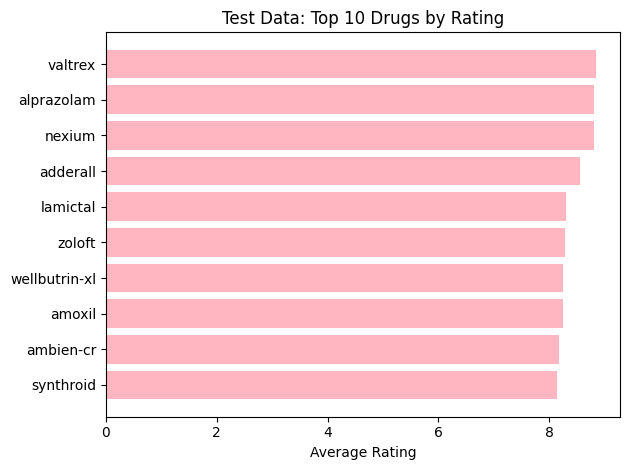

In [26]:
#Top drugs by average rating – TEST

test_drug_stats = (
    test_df
      .groupby("urlDrugName")["rating"]
      .agg(["mean", "count", "std"])
      .reset_index()
)

# Sort by average rating (descending)
test_drug_stats = test_drug_stats.sort_values("mean", ascending=False)

# Keep drugs with at least 5 reviews
test_drug_stats_filtered = test_drug_stats[test_drug_stats["count"] >= 5]

print("\nTop 20 drugs by average rating (min 5 reviews) – TEST:")
print(test_drug_stats_filtered.head(20).round(2))

print(f"\nTotal unique drugs: {len(test_drug_stats)}")
print(f"Drugs with ≥3 reviews: {len(test_drug_stats_filtered)}")

#  bar chart – top 10 drugs
top_test_drugs = test_drug_stats_filtered.head(10)
plt.barh(top_test_drugs["urlDrugName"], top_test_drugs["mean"], color='lightpink')
plt.xlabel("Average Rating")
plt.title("Test Data: Top 10 Drugs by Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Identify distinctive terms for high‑rating vs low‑rating reviews.

In [27]:
# TF‑IDF top terms helper
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, stop_words='english')

for label in ['positive','negative']:
    sub = train_df[train_df['actual_label'] == label]

    X = vectorizer.fit_transform(sub['overall_review'])
    terms = np.array(vectorizer.get_feature_names_out())
    tfidf_means = np.asarray(X.mean(axis=0)).ravel()
    top_idx = tfidf_means.argsort()[::-1][:20]
    print(f"Top terms for {label} ratings:")
    for t, v in zip(terms[top_idx], tfidf_means[top_idx]):
        print(f"{t:25s} {v:.4f}")

Top terms for positive ratings:
day                       0.0307
effects                   0.0269
taking                    0.0259
pain                      0.0259
drug                      0.0232
medication                0.0221
skin                      0.0220
treatment                 0.0198
time                      0.0198
did                       0.0191
days                      0.0185
mg                        0.0177
sleep                     0.0176
took                      0.0176
years                     0.0170
daily                     0.0166
night                     0.0161
pill                      0.0159
feel                      0.0159
dose                      0.0149
Top terms for negative ratings:
pain                      0.0374
drug                      0.0343
day                       0.0336
effects                   0.0335
taking                    0.0320
did                       0.0309
medication                0.0256
severe                    0.0244
took        

In [28]:
# TF‑IDF top terms helper
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, stop_words='english')

for label in ['positive','negative']:
    sub = test_df[test_df['actual_label'] == label]

    X = vectorizer.fit_transform(sub['overall_review'])
    terms = np.array(vectorizer.get_feature_names_out())
    tfidf_means = np.asarray(X.mean(axis=0)).ravel()
    top_idx = tfidf_means.argsort()[::-1][:20]
    print(f"Top terms for {label} ratings:")
    for t, v in zip(terms[top_idx], tfidf_means[top_idx]):
        print(f"{t:25s} {v:.4f}")

Top terms for positive ratings:
day                       0.0357
effects                   0.0326
taking                    0.0317
skin                      0.0310
drug                      0.0289
pain                      0.0270
mg                        0.0250
medication                0.0247
did                       0.0239
days                      0.0238
time                      0.0238
took                      0.0222
sleep                     0.0220
treatment                 0.0213
months                    0.0212
years                     0.0204
daily                     0.0202
feel                      0.0199
night                     0.0196
pill                      0.0192
Top terms for negative ratings:
pain                      0.0490
day                       0.0443
drug                      0.0429
taking                    0.0405
effects                   0.0392
days                      0.0358
did                       0.0357
medication                0.0328
took        

### Word clouds

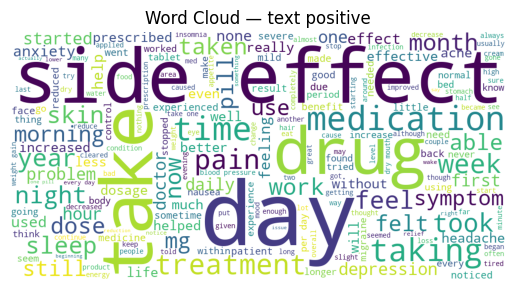

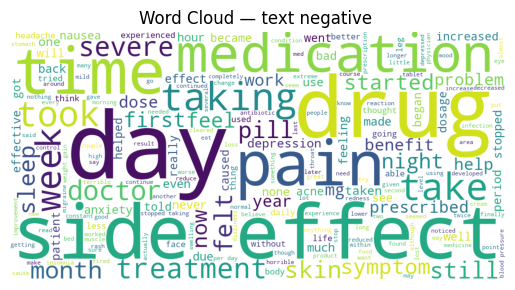

In [29]:
from wordcloud import WordCloud
wc = WordCloud(width=1000, height=500, background_color='white', max_words=200)

text_positive = ' '.join(train_df.loc[train_df.get('actual_label')=='positive','overall_review'].tolist())
text_negative  = ' '.join(train_df.loc[train_df.get('actual_label')=='negative','overall_review'].tolist())

if text_positive:
    plt.imshow(wc.generate(text_positive))
    plt.axis('off')
    plt.title('Word Cloud — text positive')
    plt.show()

if text_negative:
    plt.imshow(wc.generate(text_negative))
    plt.axis('off')
    plt.title('Word Cloud — text negative ')
    plt.show()


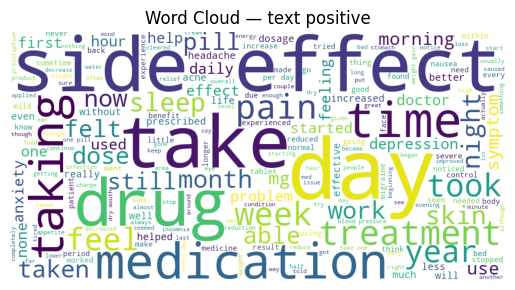

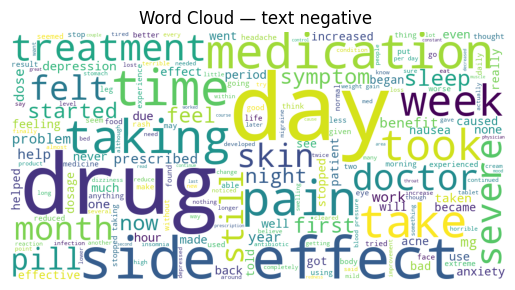

In [30]:
text_positive_test = ' '.join(test_df.loc[test_df.get('actual_label')=='positive','overall_review'].tolist())
text_negative_test  = ' '.join(test_df.loc[test_df.get('actual_label')=='negative','overall_review'].tolist())

if text_positive_test:
    plt.imshow(wc.generate(text_positive))
    plt.axis('off')
    plt.title('Word Cloud — text positive')
    plt.show()

if text_negative_test:
    plt.imshow(wc.generate(text_negative))
    plt.axis('off')
    plt.title('Word Cloud — text negative ')
    plt.show()


## Part II: Sentiment Analysis & NLP (60pts)



### Use Vader sentiment analysis (20pts)
- apply vader SentimentIntensityAnalyzer on the overall_review.
- add the compound score to the dataframe.
- add vader_label column as 'positive' if compound >0 and negative otherwise.
- calculate the sentiment classification accuracy out of Vader.

In [31]:
import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report

# VADER sentiment
sia = SentimentIntensityAnalyzer()

# 1) get compound score from overall_review
train_df['vader_compound'] = train_df['overall_review'].fillna('').apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# 2) create vader_label: 'positive' if compound > 0, else 'negative'
train_df['vader_label'] = train_df['vader_compound'].apply(
    lambda x: 'positive' if x > 0 else 'negative'
)

# 3) calculate accuracy vs actual_label
train_accuracy = accuracy_score(train_df['actual_label'], train_df['vader_label'])
print(f"VADER sentiment accuracy on TRAIN: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")


VADER sentiment accuracy on TRAIN: 0.5623 (56.23%)


In [32]:
#Apply VADER on TEST data 
test_df['vader_compound'] = test_df['overall_review'].fillna('').apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

test_df['vader_label'] = test_df['vader_compound'].apply(
    lambda c: 'positive' if c > 0 else 'negative'
)

test_accuracy = accuracy_score(test_df['actual_label'], test_df['vader_label'])
print(f"VADER sentiment accuracy on TEST: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

VADER sentiment accuracy on TEST: 0.5396 (53.96%)


Calculate the accuracy score

### Sentiment Analysis using Bio_ClinicalBERT (30pts)


Use Bio_ClinicalBERT for sentiment analysis on the Drug Reviews dataset. Reuse the code below.
- Train/Test on the whole dataset
- Split the dataset into training/testing subsets
- Report the sentiment classification accuracy.



Helper code:

In [6]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
mdl = AutoModel.from_pretrained(MODEL_ID).eval().to("cuda" if torch.cuda.is_available() else "cpu")

def encode_mean(texts, batch_size= 16, max_len=256):
    enc = tok(texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    enc = {k: v.to(mdl.device) for k, v in enc.items()}
    with torch.no_grad():
        out = mdl(**enc).last_hidden_state
        attn = enc["attention_mask"].unsqueeze(-1)
        mean_emb = (out * attn).sum(1) / attn.sum(1).clamp_min(1e-9)
    return mean_emb.cpu().numpy()

# Fill missing reviews
train_df["overall_review"] = train_df["overall_review"].fillna("")
test_df["overall_review"] = test_df["overall_review"].fillna("")

# Binary labels: positive -> 1, negative -> 0
train_df["label_encoded"] = (train_df["actual_label"] == "positive").astype(int)
test_df["label_encoded"] = (test_df["actual_label"] == "positive").astype(int)

y_train = train_df["label_encoded"].values
y_test = test_df["label_encoded"].values

print("Train label distribution:")
print(train_df["label_encoded"].value_counts())
print("\nTest label distribution:")
print(test_df["label_encoded"].value_counts())


/Users/thukzomm/jupyter_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train label distribution:
label_encoded
1    2287
0     820
Name: count, dtype: int64

Test label distribution:
label_encoded
1    728
0    308
Name: count, dtype: int64


In [7]:
# Encode text with BERT
X_train = encode_mean(train_df["overall_review"].astype(str).tolist(), max_len=128)

In [8]:
X_test = encode_mean(test_df["overall_review"].astype(str).tolist(), max_len=128)

print(f"Train embeddings shape: {X_train.shape}")
print(f"Test embeddings shape:  {X_test.shape}")


Train embeddings shape: (3107, 768)
Test embeddings shape:  (1036, 768)


In [13]:
from sklearn.metrics import accuracy_score
# Train classifier
clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Bio_ClinicalBERT Sentiment Classification Results")
print(f"Accuracy on test set: {accuracy:.4f} ({accuracy*100:.2f}%)\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


def polarity_from_clinicalbert(text: str):
    if text is None or not str(text).strip():
        return 0.0, "neutral"
    emb = encode_mean([text])
    prob = clf.predict_proba(emb)[0]  # [p_neg, p_pos] if binary
    score = prob[1] - prob[0]         # signed polarity in [-1, 1] approximately
    label = "positive" if score > 0 else "negative"
    return float(score), label



Bio_ClinicalBERT Sentiment Classification Results
Accuracy on test set: 0.7278 (72.78%)

Classification report:
              precision    recall  f1-score   support

    negative       0.54      0.63      0.58       308
    positive       0.83      0.77      0.80       728

    accuracy                           0.73      1036
   macro avg       0.68      0.70      0.69      1036
weighted avg       0.74      0.73      0.73      1036



In [14]:
text= "The antibiotic may have destroyed bacteria causing my sinus infection. But it may also have been caused by a virus, so its hard to say. Some back pain, some nauseau. Took the antibiotics for 14 days. Sinus infection was gone after the 6th day."
print(polarity_from_clinicalbert(text))


(0.6585360525749748, 'positive')


In [15]:
text = "This medication helped my pain a lot with no side effects."
print(polarity_from_clinicalbert(text))


(0.9708425795396161, 'positive')


### Sentiment polarity score versus label Visualization (10pts)
- show the density plot of the compound score per actual_label
- show the density plot of the polarity_from_clinicalbert score per actual_label
- comment on the plots

In [16]:
# Compute polarity score for each review using Bio_ClinicalBERT
print("Computing polarity scores for all test reviews...")

test_df["bert_polarity_score"] = test_df["overall_review"].apply(
    lambda x: polarity_from_clinicalbert(x)[0]
)


Computing polarity scores for all test reviews...


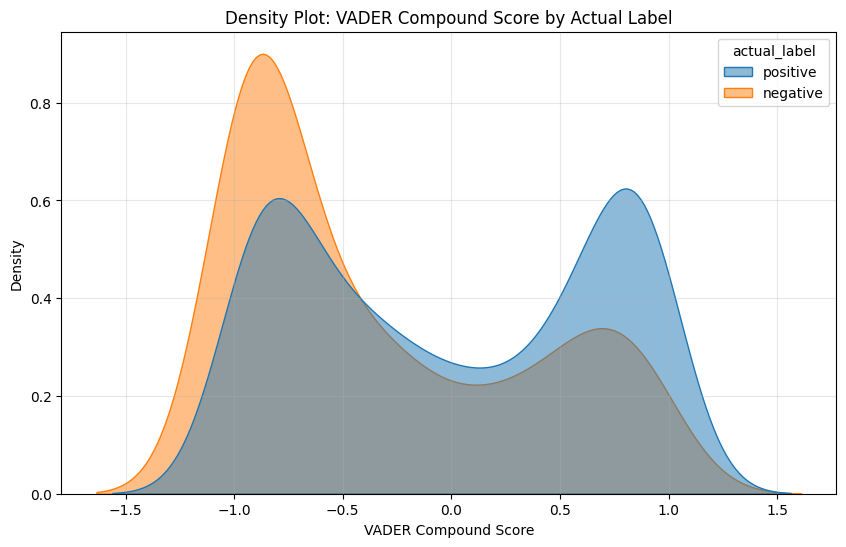

In [33]:

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=test_df,
    x="vader_compound",
    hue="actual_label",
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.title("Density Plot: VADER Compound Score by Actual Label")
plt.xlabel("VADER Compound Score")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


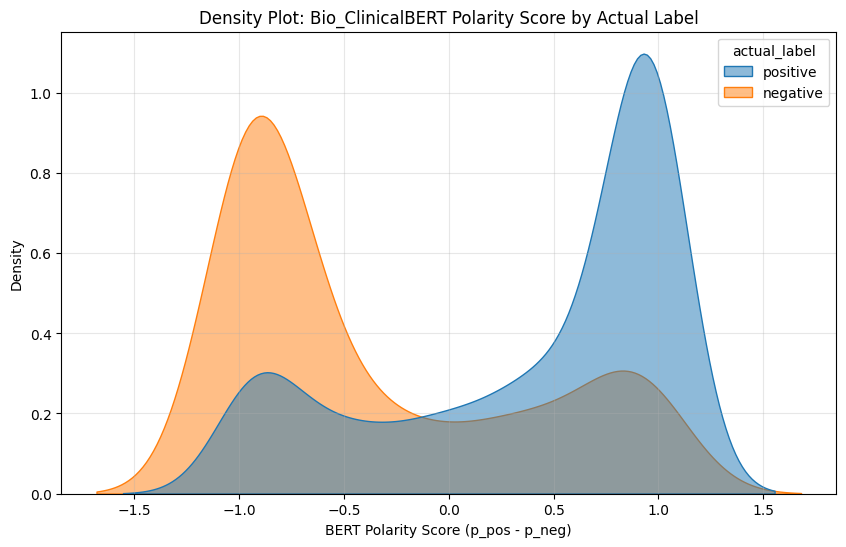

In [34]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=test_df,
    x="bert_polarity_score",
    hue="actual_label",
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.title("Density Plot: Bio_ClinicalBERT Polarity Score by Actual Label")
plt.xlabel("BERT Polarity Score (p_pos - p_neg)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()
